# Crawling & Analisis Data Polutan Udara di Kecamatan Waru, Kabupaten Pamekasan

<!-- # Pemantauan Kualitas Udara Kecamatan Waru Berbasis Data Satelit Sentinel-5P -->

Nama : Rian Renaldy

NIM : 240411100053

Mata Kuliah : Pengantar Sains Data (PSD)

## Gambaran Wilayah Analisa

Kecamatan Waru terletak di Kabupaten Pamekasan, Pulau Madura, Provinsi Jawa Timur. Berbeda dari kawasan industri besar, karakter utama wilayah ini didominasi oleh **sektor agraris** (padi, jagung) dan **peternakan sapi Madura** &mdash; Kecamatan Waru bahkan telah ditetapkan Pemerintah Kabupaten Pamekasan sebagai salah satu **sentra peternakan sapi Madura**, sekaligus tergabung dalam kawasan agropolitan RUPANANDUR (Waru, Pakong, Pegantenan, Kadur). Selain itu, jalur distribusi barang lintas Madura (menghubungkan Bangkalan &ndash; Sampang &ndash; Pamekasan &ndash; Sumenep) turut menyumbang emisi kendaraan bermotor yang melintasi wilayah ini. Kombinasi aktivitas pertanian, peternakan sapi, dan transportasi darat ini berpotensi memengaruhi konsentrasi berbagai gas pencemar udara, meliputi Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Sulfur Dioksida (SO2), Ozon troposferik (O3), Formaldehida (HCHO), dan Metana (CH4). Pemantauan keenam gas tersebut dari waktu ke waktu diperlukan untuk memahami karakteristik kualitas udara di Kecamatan Waru.


## 1. Business Understanding

### 1.1 Latar Belakang

Pemantauan kualitas udara menjadi hal penting untuk dilakukan, mengingat polutan di atmosfer dapat bersumber dari berbagai aktivitas manusia (transportasi, industri, maupun pertanian) ataupun dari proses alami. Komposisi sumber polutan ini dapat berbeda-beda antarwilayah, bergantung pada karakteristik ekonomi dan geografis masing-masing daerah. Kecamatan Waru sendiri memiliki karakteristik khas, yaitu sebagai salah satu sentra peternakan sapi Madura di Kabupaten Pamekasan, dengan aktivitas pertanian dan jalur lintas transportasi di Pulau Madura, yang berpotensi menjadi sumber emisi tersendiri bagi tiap jenis polutan. Analisis pada tugas ini difokuskan pada enam jenis polutan udara di wilayah Kecamatan Waru dengan memanfaatkan data satelit Sentinel-5P selama periode pengamatan kurang lebih satu tahun.

### 1.2 Tujuan Analisis

Menelusuri sumber-sumber utama polutan udara serta memetakan kondisi kualitas udara di wilayah Kecamatan Waru, melalui pengambilan data satelit untuk enam parameter (CO, NO2, SO2, O3, HCHO, CH4), dilanjutkan dengan eksplorasi data (*data understanding*), dan divisualisasikan dalam bentuk *time series* untuk rentang waktu minimal satu tahun hingga 31 Agustus 2026.

### 1.3 Manfaat Analisis

1. Memetakan pola naik-turunnya konsentrasi tiap gas pencemar di Kecamatan Waru sepanjang periode pengamatan.
2. Menduga kontribusi aktivitas lokal (pertanian, peternakan sapi Madura, transportasi) terhadap tiap jenis polutan.
3. Menyediakan gambaran awal kualitas udara yang bisa menjadi rujukan warga maupun pemangku kebijakan setempat.
4. Menjadi pijakan data (baseline) untuk tahap pembersihan data dan pemodelan pada pertemuan berikutnya.
5. Melatih keterampilan pengambilan data satelit (remote sensing crawling) serta eksplorasi data deret waktu lingkungan.

### 1.4 Dugaan Sumber Tiap Polutan

| Polutan | Apa Itu? | Dugaan Sumber di Kecamatan Waru |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas tak berwarna & tak berbau, terbentuk dari pembakaran bahan bakar yang tidak sempurna | Knalpot kendaraan bermotor di jalur lintas Madura, pembakaran jerami/lahan pertanian sisa panen |
| **NO2** (Nitrogen Dioksida) | Gas oksida nitrogen hasil pembakaran suhu tinggi | Emisi kendaraan bermotor di jalur lintas Madura, genset/mesin diesel pada aktivitas peternakan dan penggilingan |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung unsur belerang | Pembakaran bahan bakar fosil skala kecil, mesin diesel kendaraan dan alat pertanian |
| **O3** (Ozon Troposferik) | Bukan diemisikan langsung; polutan sekunder hasil reaksi fotokimia NOx dengan senyawa organik volatil di bawah sinar matahari | Terbentuk secara tidak langsung dari interaksi emisi kendaraan dan sinar matahari, umum meningkat pada siang hari cerah |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC) hasil oksidasi hidrokarbon di atmosfer | Pembakaran biomassa/limbah pertanian, oksidasi metana dari peternakan sapi, serta emisi kendaraan bermotor |
| **CH4** (Metana) | Gas rumah kaca, terkait erat dengan siklus biologis | Fermentasi enterik ternak sapi Madura (sentra peternakan di Kecamatan Waru), lahan sawah tergenang air, dan dekomposisi limbah organik |

### 1.5 Deskripsi Umum Data

Data yang dipakai bersumber dari misi satelit **Sentinel-5P (instrumen TROPOMI)** yang dikelola oleh Copernicus/ESA, diakses melalui layanan **openEO** pada **Copernicus Data Space Ecosystem (CDSE)**. Data berupa nilai kerapatan kolom (*column density*) harian tiap gas pada resolusi grid tertentu, yang kemudian dirata-ratakan dalam batas wilayah analisa untuk membentuk satu nilai per hari per polutan.


## 2. Data Understanding
### 2.1 Penetapan Area Analisa (AOI) Melalui Berkas GeoJSON Batas Kecamatan

Batas wilayah Kecamatan Waru diperoleh dari situs **[batas-admin.geoit.dev](https://batas-admin.geoit.dev/)**, yang menyediakan berkas batas administratif resmi untuk seluruh wilayah Indonesia hingga tingkat kecamatan. Peta Kecamatan Waru yang telah termuat pada situs tersebut ditunjukkan pada gambar berikut.

![image](https://hackmd.io/_uploads/HJB0Z9fYGx.jpg)

Saat mengunduh berkas GeoJSON, tingkat wilayah yang dipilih adalah **kecamatan**, bukan kelurahan/desa. Hal ini penting agar batas yang diunduh berupa satu poligon utuh Kecamatan Waru, bukan poligon yang terpisah-pisah per desa/kelurahan di dalamnya.

![image](https://hackmd.io/_uploads/BkiZzqGtMx.png)


Berbeda dari pendekatan menggambar manual di [geojson.io](https://geojson.io) (yang dipakai pada cakupan kabupaten sebelumnya), batas wilayah Kecamatan Waru diperoleh dari **berkas GeoJSON batas administratif resmi** (`Kecamatan_Waru-KECAMATAN.geojson`) yang diunggah langsung ke Colab, karena bentuk poligon kecamatan terlalu detail (ribuan titik koordinat) untuk digambar ulang secara manual. Poligon tersebut kemudian **disederhanakan (simplify)** agar jumlah titiknya lebih ringkas, sebelum dihitung *bounding box*-nya sebagai parameter `spatial_extent` saat memanggil data pada openEO.


In [1]:
!pip install geopandas


Penjelasan kode di atas adalah sebagai berikut.

- Baris `!pip install geopandas` memasang pustaka `geopandas`, yang dipakai untuk membaca, menyederhanakan, dan mengolah berkas GeoJSON batas wilayah.


In [2]:
import geopandas as gpd
import json

gdf_waru = gpd.read_file("Kecamatan_Waru-KECAMATAN.geojson")

print("Jumlah fitur:", len(gdf_waru))
print("Kolom:", list(gdf_waru.columns))
print(gdf_waru[["kecamatan", "kab_kota", "provinsi"]])

gdf_waru["geometry"] = gdf_waru.geometry.simplify(tolerance=0.001, preserve_topology=True)

aoi_waru = json.loads(gdf_waru.to_json())

print("Boundary Kecamatan Waru berhasil dimuat & disederhanakan.")


Jumlah fitur: 1
Kolom: ['kode_kec', 'kode_kk', 'kode_prov', 'kecamatan', 'kab_kota', 'provinsi', 'fid', 'nama', 'label', 'geometry']
  kecamatan   kab_kota    provinsi
0      Waru  Pamekasan  Jawa Timur
Boundary Kecamatan Waru berhasil dimuat & disederhanakan.


Penjelasan kode di atas adalah sebagai berikut.

- `gpd.read_file("Kecamatan_Waru-KECAMATAN.geojson")` membaca berkas GeoJSON batas administratif Kecamatan Waru yang telah diunggah ke Colab, sehingga tidak perlu menuliskan koordinat poligon secara manual.
- `gdf_waru.geometry.simplify(tolerance=0.001, preserve_topology=True)` menyederhanakan bentuk poligon (mengurangi jumlah titik koordinat) sambil mempertahankan bentuk topologi wilayahnya, karena openEO tidak memerlukan tingkat detail poligon yang terlalu tinggi.
- `json.loads(gdf_waru.to_json())` mengonversi hasilnya kembali menjadi struktur GeoJSON (dict) pada variabel `aoi_waru`, yang dipakai pada tahap perhitungan *bounding box* selanjutnya.


In [3]:
titik_poligon = aoi_waru["features"][0]["geometry"]["coordinates"][0]
daftar_lon = [titik[0] for titik in titik_poligon]
daftar_lat = [titik[1] for titik in titik_poligon]

kotak_wilayah = {
    "west": min(daftar_lon),
    "south": min(daftar_lat),
    "east": max(daftar_lon),
    "north": max(daftar_lat),
}

print("Bounding box wilayah Analisa (Kecamatan Waru):")
print(kotak_wilayah)


Bounding box wilayah Analisa (Kecamatan Waru):
{'west': 113.518619586, 'south': -7.02284536399998, 'east': 113.619138379, 'north': -6.91929247599995}


Penjelasan kode di atas adalah sebagai berikut.

- Variabel `aoi_waru` menyimpan poligon GeoJSON batas Kecamatan Waru yang telah disederhanakan pada langkah sebelumnya.
- Daftar koordinat bujur (`daftar_lon`) dan lintang (`daftar_lat`) diekstrak dari titik-titik poligon fitur pertama untuk menghitung *bounding box* &mdash; kotak pembatas terluar dari poligon tersebut.
- Variabel `kotak_wilayah` (berisi `west`, `south`, `east`, `north`) inilah yang dipakai sebagai parameter `spatial_extent` saat memanggil data pada openEO, karena openEO membutuhkan bentuk kotak pembatas, bukan poligon kompleks, untuk membatasi area unduhan awal.


![image](https://hackmd.io/_uploads/rkxNEl9zYGx.png)

### 2.2 Pengambilan Data (Crawling) dengan openEO &mdash; Copernicus Data Space Ecosystem

#### 2.2.1 Instalasi & Autentikasi

In [4]:
!pip install openeo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Penjelasan kode di atas adalah sebagai berikut.

- Baris `!pip install openeo` memasang pustaka `openeo`, antarmuka Python untuk mengakses data satelit pada Copernicus Data Space Ecosystem.

In [5]:
import openeo

koneksi = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=YEHF-ENHJ 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Penjelasan kode di atas adalah sebagai berikut.

- `openeo.connect("openeo.dataspace.copernicus.eu")` membuka koneksi ke server openEO milik Copernicus.
- `.authenticate_oidc()` menjalankan proses autentikasi (login) menggunakan akun Copernicus; menjalankan baris ini akan menampilkan tautan autentikasi yang perlu dibuka dan disetujui terlebih dahulu sebelum pengambilan data dapat dilanjutkan.

### 2.3 Mengunduh Enam Parameter Polutan

Rentang waktu ditetapkan **1 tahun penuh**, dari **31 Agustus 2025** sampai **31 Agustus 2026**, memenuhi ketentuan tugas (data terkini, minimal satu tahun sampai 31 Agustus 2026). Perlu diperhatikan, parameter akhir (`tanggal_akhir`) pada `temporal_extent` bersifat *exclusive* (tanggal itu sendiri tidak ikut disertakan), sehingga nilainya ditetapkan **1 September 2026**, bukan 31 Agustus 2026 — dengan begitu, data pada tanggal 31 Agustus 2026 tetap ikut terambil sepenuhnya. Karena koleksi `SENTINEL_5P_L2` pada openEO hanya mengizinkan satu *band* per permintaan, pengambilan data dilakukan bergiliran untuk tiap polutan menggunakan perulangan, dan masing-masing hasil disimpan sebagai berkas NetCDF (`.nc`) terpisah.

> **Catatan:** jika notebook dijalankan sebelum tanggal 31 Agustus 2026, cakupan data hanya akan sampai pada tanggal perekaman satelit terakhir yang tersedia saat itu. Jalankan ulang mendekati/setelah tanggal tersebut untuk mendapatkan rentang data yang benar-benar penuh satu tahun.

In [6]:
daftar_polutan = ["CO", "NO2", "SO2", "O3", "HCHO", "CH4"]

tanggal_mulai = "2025-08-31"
tanggal_akhir = "2026-09-01"

for gas in daftar_polutan:
    kubus_data = koneksi.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[tanggal_mulai, tanggal_akhir],
        spatial_extent=kotak_wilayah,
        bands=[gas],
    )
    kubus_harian = kubus_data.aggregate_temporal_period(reducer="mean", period="day")
    kubus_harian.execute_batch(title=f"{gas} Kecamatan Waru", outputfile=f"{gas}_waru.nc")
    print(f"Data {gas} selesai diunduh -> {gas}_waru.nc")


0:00:00 Job 'j-26091213010248848b80a6a1928b9a13': send 'start'
0:00:03 Job 'j-26091213010248848b80a6a1928b9a13': created (progress 0%)
0:00:08 Job 'j-26091213010248848b80a6a1928b9a13': queued (progress 0%)
0:00:15 Job 'j-26091213010248848b80a6a1928b9a13': queued (progress 0%)
0:00:23 Job 'j-26091213010248848b80a6a1928b9a13': queued (progress 0%)
0:00:33 Job 'j-26091213010248848b80a6a1928b9a13': queued (progress 0%)
0:00:45 Job 'j-26091213010248848b80a6a1928b9a13': queued (progress 0%)
0:01:01 Job 'j-26091213010248848b80a6a1928b9a13': queued (progress 0%)
0:01:20 Job 'j-26091213010248848b80a6a1928b9a13': running (progress N/A)
0:01:44 Job 'j-26091213010248848b80a6a1928b9a13': running (progress N/A)
0:02:14 Job 'j-26091213010248848b80a6a1928b9a13': running (progress N/A)
0:02:52 Job 'j-26091213010248848b80a6a1928b9a13': running (progress N/A)
0:03:39 Job 'j-26091213010248848b80a6a1928b9a13': finished (progress 100%)
Data CO selesai diunduh -> CO_waru.nc
0:00:00 Job 'j-2609121304484610be8

Penjelasan kode di atas adalah sebagai berikut.

- Perulangan `for gas in daftar_polutan` memproses keenam polutan satu per satu, karena koleksi `SENTINEL_5P_L2` pada openEO hanya mengizinkan satu *band* per permintaan.
- `koneksi.load_collection()` mengambil data mentah sesuai rentang waktu (`temporal_extent`) dan wilayah (`spatial_extent`) yang ditentukan, untuk satu polutan (`bands=[gas]`) pada satu waktu.
- `.aggregate_temporal_period(reducer="mean", period="day")` mengagregasi data menjadi rata-rata harian.
- `.execute_batch()` menjalankan proses pengambilan data secara *batch* di server openEO dan menyimpan hasilnya sebagai berkas NetCDF (`.nc`) terpisah untuk tiap polutan.

Status N/A yang muncul pada proses running dapat diabaikan karena hanya menunjukkan bahwa persentase progres tidak dapat ditampilkan oleh server pada saat itu. Selama status job masih berada pada kondisi running, proses pengolahan data tetap berjalan normal.
Selain melalui terminal, proses pengambilan data juga dapat dipantau melalui halaman OpenEO Editor:

[openEO Web Editor](https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2)

Pada halaman tersebut akan ditampilkan daftar job yang pernah dijalankan, termasuk nama dataset, status proses, waktu eksekusi, serta file hasil yang dapat diunduh setelah proses selesai. Dengan demikian, pengguna dapat memantau perkembangan pengambilan data secara langsung hingga status berubah menjadi finished.

> ![image](https://hackmd.io/_uploads/H1WIpKGFzg.png)

### 2.4 Membaca Berkas NetCDF & Menyimpan sebagai CSV

Tiap berkas `.nc` dibuka menggunakan `netCDF4`, dihitung rata-rata harian pada seluruh grid dalam wilayah analisa (mengabaikan piksel yang tertutup awan/*masked*), lalu digabungkan berdasarkan tanggal menjadi satu tabel dan disimpan ke satu berkas CSV.

In [7]:
!pip install netCDF4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.6 MB/s eta 0:00:00


Penjelasan kode di atas adalah sebagai berikut.

- Baris `!pip install netCDF4` memasang pustaka `netCDF4`, yang dipakai untuk membaca berkas hasil unduhan Sentinel-5P berformat NetCDF (`.nc`).

In [8]:
import netCDF4
import numpy as np
import pandas as pd


def baca_rata_rata_harian(nama_band, nama_berkas):
    dataset = netCDF4.Dataset(nama_berkas)

    nilai = dataset.variables[nama_band][:]
    waktu = dataset.variables["t"][:]
    satuan_waktu = dataset.variables["t"].units

    tanggal = netCDF4.num2date(waktu, units=satuan_waktu)
    tanggal_harian = [t.strftime("%Y-%m-%d") for t in tanggal]

    rata_harian = []
    for idx in range(len(nilai)):
        grid_harian = nilai[idx]
        nilai_rata = np.ma.mean(grid_harian)

        if np.ma.is_masked(nilai_rata):
            nilai_rata = np.nan
        else:
            nilai_rata = float(nilai_rata)

        rata_harian.append(nilai_rata)

    df_hasil = pd.DataFrame({"tanggal": tanggal_harian, nama_band: rata_harian})
    df_hasil["tanggal"] = pd.to_datetime(df_hasil["tanggal"])
    df_hasil[nama_band] = pd.to_numeric(df_hasil[nama_band], errors="coerce")

    return df_hasil


kumpulan_df = {}
for gas in daftar_polutan:
    df_gas = baca_rata_rata_harian(gas, f"{gas}_waru.nc")
    kumpulan_df[gas] = df_gas
    print(f"{gas}: {df_gas.shape[0]} baris berhasil dibaca")

# Gabungkan seluruh polutan berdasarkan kolom tanggal
df_polutan_waru = kumpulan_df[daftar_polutan[0]][["tanggal"]].copy()
for gas in daftar_polutan:
    df_polutan_waru = df_polutan_waru.merge(
        kumpulan_df[gas][["tanggal", gas]], on="tanggal", how="outer"
    )

df_polutan_waru = df_polutan_waru.sort_values("tanggal").reset_index(drop=True)
df_polutan_waru.to_csv("data_polutan_waru.csv", index=False)

print(f"\nBerhasil menyimpan {len(df_polutan_waru)} baris ke data_polutan_waru.csv")


CO: 366 baris berhasil dibaca
NO2: 364 baris berhasil dibaca
SO2: 353 baris berhasil dibaca
O3: 363 baris berhasil dibaca
HCHO: 353 baris berhasil dibaca
CH4: 212 baris berhasil dibaca

Berhasil menyimpan 366 baris ke data_polutan_waru.csv


Penjelasan kode di atas adalah sebagai berikut.

- Fungsi `baca_rata_rata_harian()` membuka satu berkas NetCDF dengan `netCDF4.Dataset()`, lalu mengambil variabel nilai polutan serta variabel waktu (`t`) di dalamnya.
- `netCDF4.num2date()` mengonversi nilai waktu numerik pada berkas NetCDF menjadi tanggal kalender yang bisa dibaca.
- Untuk tiap hari, `np.ma.mean()` menghitung rata-rata nilai dari seluruh grid/piksel dalam wilayah analisa; apabila seluruh piksel tertutup awan (`np.ma.is_masked`), nilainya diisi `NaN`.
- Perulangan `for gas in daftar_polutan` menjalankan fungsi tersebut untuk keenam berkas `.nc`, lalu digabungkan (`merge(..., how="outer")`) berdasarkan kolom `tanggal`, sehingga tanggal yang tidak memiliki nilai pada satu polutan tetap tersimpan sebagai `NaN`, bukan hilang dari tabel.
- Tabel gabungan diurutkan berdasarkan tanggal dan disimpan sebagai `data_polutan_waru.csv`.

> ![image](https://hackmd.io/_uploads/SyT7CFMtzx.png)

Berkas hasil unduhan kemudian diperiksa untuk melihat hasil pengambilan data.

> ![image](https://hackmd.io/_uploads/ByD1CFGYfe.png)




### 2.5 Eksplorasi Struktur & Isi Data

In [9]:
print("=== Struktur Data Polutan Kecamatan Waru ===")
df_polutan_waru.info()

print("\n=== Ukuran Dataset ===")
print("Jumlah baris :", df_polutan_waru.shape[0])
print("Jumlah kolom :", df_polutan_waru.shape[1])

print("\n=== Nama Kolom ===")
print(df_polutan_waru.columns.tolist())


=== Struktur Data Polutan Kecamatan Waru ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   tanggal  366 non-null    datetime64[ns]
 1   CO       225 non-null    float64       
 2   NO2      193 non-null    float64       
 3   SO2      217 non-null    float64       
 4   O3       362 non-null    float64       
 5   HCHO     231 non-null    float64       
 6   CH4      20 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.1 KB

=== Ukuran Dataset ===
Jumlah baris : 366
Jumlah kolom : 7

=== Nama Kolom ===
['tanggal', 'CO', 'NO2', 'SO2', 'O3', 'HCHO', 'CH4']


Penjelasan kode di atas adalah sebagai berikut.

- `df_polutan_waru.info()` menampilkan ringkasan struktur data: jumlah baris, nama kolom, jumlah nilai non-kosong, dan tipe data tiap kolom.
- `.shape` memberi jumlah baris dan kolom, sedangkan `.columns.tolist()` menampilkan daftar nama kolom.

In [10]:

print("\n=== Lima Data Teratas ===")
display(df_polutan_waru.head())

print("\n=== Lima Data Terbawah ===")
display(df_polutan_waru.tail())


=== Lima Data Teratas ===


,tanggal,CO,NO2,SO2,O3,HCHO,CH4
0,2025-08-31,0.028565,0.000006,-0.000031,0.116010,0.000093,NaN
1,2025-09-01,0.025179,0.000011,-0.000122,0.114705,0.000055,NaN
2,2025-09-02,0.024256,0.000006,-0.000036,0.114179,0.000052,NaN
3,2025-09-03,0.025893,0.000006,0.000212,0.114352,0.000136,NaN
4,2025-09-04,0.025961,0.000011,0.000085,0.113113,0.000045,1849.052246



=== Lima Data Terbawah ===


,tanggal,CO,NO2,SO2,O3,HCHO,CH4
361,2026-08-27,0.029996,0.000020,0.000083,0.117833,0.000237,NaN
362,2026-08-28,0.031108,0.000017,0.000039,0.115966,0.000179,1895.127539
363,2026-08-29,NaN,0.000010,-0.000087,0.116782,0.000073,NaN
364,2026-08-30,0.030288,0.000007,-0.000011,0.115068,0.000053,NaN
365,2026-08-31,0.027979,0.000008,0.000038,0.116428,0.000042,NaN


Penjelasan kode di atas adalah sebagai berikut.

- `.head()` dan `.tail()` menampilkan lima baris data teratas dan terbawah, untuk memeriksa sekilas format serta rentang tanggal data secara langsung.

In [11]:
print("\n=== Cek tanggal yang tidak ada di data ===")

semua_tanggal = pd.date_range(start=df_polutan_waru["tanggal"].min(), end=df_polutan_waru["tanggal"].max())
tanggal_hilang = semua_tanggal.difference(df_polutan_waru["tanggal"])
print(f"Jumlah tanggal hilang: {len(tanggal_hilang)}")
print(tanggal_hilang)


=== Cek tanggal yang tidak ada di data ===
Jumlah tanggal hilang: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


Penjelasan kode di atas adalah sebagai berikut.

- `pd.date_range()` menghasilkan daftar seluruh tanggal dari awal hingga akhir periode data secara berurutan tanpa ada yang terlewat.
- `.difference(df_polutan_waru["tanggal"])` membandingkan daftar tersebut dengan tanggal yang benar-benar tercatat, sehingga diperoleh tanggal yang hilang sepenuhnya (tidak memiliki nilai pada satu pun polutan) — kemungkinan karena wilayah kajian tertutup awan secara penuh pada tanggal tersebut.

### 2.6 Penjelasan Tiap Fitur

- **tanggal** &mdash; tanggal observasi harian (hasil agregasi rata-rata dari seluruh piksel di wilayah analisa).
- **CO** &mdash; kerapatan kolom karbon monoksida (mol/m&sup2;); indikator pembakaran tidak sempurna.
- **NO2** &mdash; kerapatan kolom nitrogen dioksida (mol/m&sup2;); indikator emisi kendaraan/pembakaran suhu tinggi.
- **SO2** &mdash; kerapatan kolom sulfur dioksida (mol/m&sup2;); indikator pembakaran bahan bakar bersulfur.
- **O3** &mdash; kerapatan kolom ozon troposferik (mol/m&sup2;); polutan sekunder hasil fotokimia.
- **HCHO** &mdash; kerapatan kolom formaldehida (mol/m&sup2;); indikator VOC dan pembakaran biomassa.
- **CH4** &mdash; kerapatan kolom metana (mol/m&sup2; atau ppb tergantung produk); terkait aktivitas biologis/peternakan/pertanian.

### 2.7 Pengecekan Missing Value

Nilai kosong (`NaN`) pada data Sentinel-5P umumnya disebabkan oleh **tutupan awan** yang menghalangi sensor optik satelit pada tanggal tertentu, bukan kesalahan pencatatan data.

In [12]:
print(f"{'Polutan':<8}{'Total Baris':<14}{'Jumlah Kosong':<16}{'Persentase':<10}")

for gas in daftar_polutan:
    total_baris = len(df_polutan_waru)
    jumlah_kosong = df_polutan_waru[gas].isna().sum()
    persentase = jumlah_kosong / total_baris * 100 if total_baris > 0 else 0
    print(f"{gas:<8}{total_baris:<14}{jumlah_kosong:<16}{persentase:.2f}%")


Polutan Total Baris   Jumlah Kosong   Persentase
CO      366           141             38.52%
NO2     366           173             47.27%
SO2     366           149             40.71%
O3      366           4               1.09%
HCHO    366           135             36.89%
CH4     366           346             94.54%


Penjelasan kode di atas adalah sebagai berikut.

- `print(f"{'Polutan':<8}...")` mencetak baris header tabel, dengan `<8`, `<14`, `<16`, `<10` mengatur lebar tiap kolom agar rapi sejajar.
- Perulangan `for gas in daftar_polutan` memproses tiap polutan satu per satu.
- `df_polutan_waru[gas].isna().sum()` menghitung jumlah baris yang bernilai kosong `(NaN)` pada kolom polutan tersebut.
- `jumlah_kosong / total_baris * 100` menghitung persentase nilai kosong terhadap total baris data.
- Baris `print()` terakhir mencetak nama polutan, total baris, jumlah kosong, dan persentasenya untuk tiap gas, dengan format lebar kolom yang sama seperti header.

### 2.8 Statistik Deskriptif

Statistik deskriptif (min, max, rata-rata, standar deviasi) serta deteksi outlier dengan metode IQR (Interquartile Range) digunakan untuk melihat sebaran nilai tiap gas sekaligus mengidentifikasi kejanggalan data.

In [13]:
ringkasan = []

for gas in daftar_polutan:
    nilai_valid = df_polutan_waru[gas].dropna()

    kuartil_1 = nilai_valid.quantile(0.25)
    kuartil_3 = nilai_valid.quantile(0.75)
    rentang_iqr = kuartil_3 - kuartil_1

    batas_bawah = kuartil_1 - 1.5 * rentang_iqr
    batas_atas = kuartil_3 + 1.5 * rentang_iqr

    jumlah_outlier = ((nilai_valid < batas_bawah) | (nilai_valid > batas_atas)).sum()

    ringkasan.append({
        "Polutan": gas,
        "Min": nilai_valid.min(),
        "Max": nilai_valid.max(),
        "Rata-rata": nilai_valid.mean(),
        "Std": nilai_valid.std(),
        "Q1": kuartil_1,
        "Q3": kuartil_3,
        "IQR": rentang_iqr,
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas,
        "Jumlah Outlier": jumlah_outlier,
    })

df_ringkasan = pd.DataFrame(ringkasan)
display(df_ringkasan)


,Polutan,Min,Max,Rata-rata,Std,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,CO,0.018891,0.036594,0.027045,0.003255,0.025128,0.029173,0.004045,0.019061,0.035239,4
1,NO2,-0.000006,0.000038,0.000015,0.000008,0.000010,0.000020,0.000009,-0.000003,0.000033,4
2,SO2,-0.000557,0.000473,0.000016,0.000128,-0.000039,0.000083,0.000122,-0.000222,0.000266,14
3,O3,0.109432,0.121933,0.115422,0.002304,0.113746,0.116700,0.002953,0.109316,0.121130,3
4,HCHO,-0.000215,0.000756,0.000110,0.000097,0.000045,0.000148,0.000102,-0.000109,0.000301,11
5,CH4,1838.171753,1925.579915,1887.095064,22.512045,1880.101034,1897.252271,17.151237,1854.374178,1922.979126,4


Penjelasan kode di atas adalah sebagai berikut.

- `dropna()` digunakan agar nilai kosong tidak ikut dihitung dalam statistik tiap polutan.
- Kuartil pertama (`Q1`) dan ketiga (`Q3`) dihitung dengan `.quantile(0.25)` dan `.quantile(0.75)`, lalu selisihnya menghasilkan `IQR`.
- Batas bawah dan atas outlier dihitung dengan rumus `Q1 - 1,5×IQR` dan `Q3 + 1,5×IQR`; nilai di luar rentang ini dihitung sebagai `jumlah_outlier`.
- Seluruh hasil (min, max, rata-rata, std, kuartil, IQR, batas, jumlah outlier) dikumpulkan per polutan ke `ringkasan`, lalu diubah menjadi tabel `df_ringkasan`.

### 2.9 Pengecekan Data Aneh (Outlier)

Selain dilihat melalui tabel ringkasan statistik pada bagian sebelumnya, sebaran nilai tiap polutan juga divisualisasikan dalam bentuk boxplot untuk mempermudah identifikasi potensi outlier secara visual berdasarkan posisi titik-titik di luar whisker.

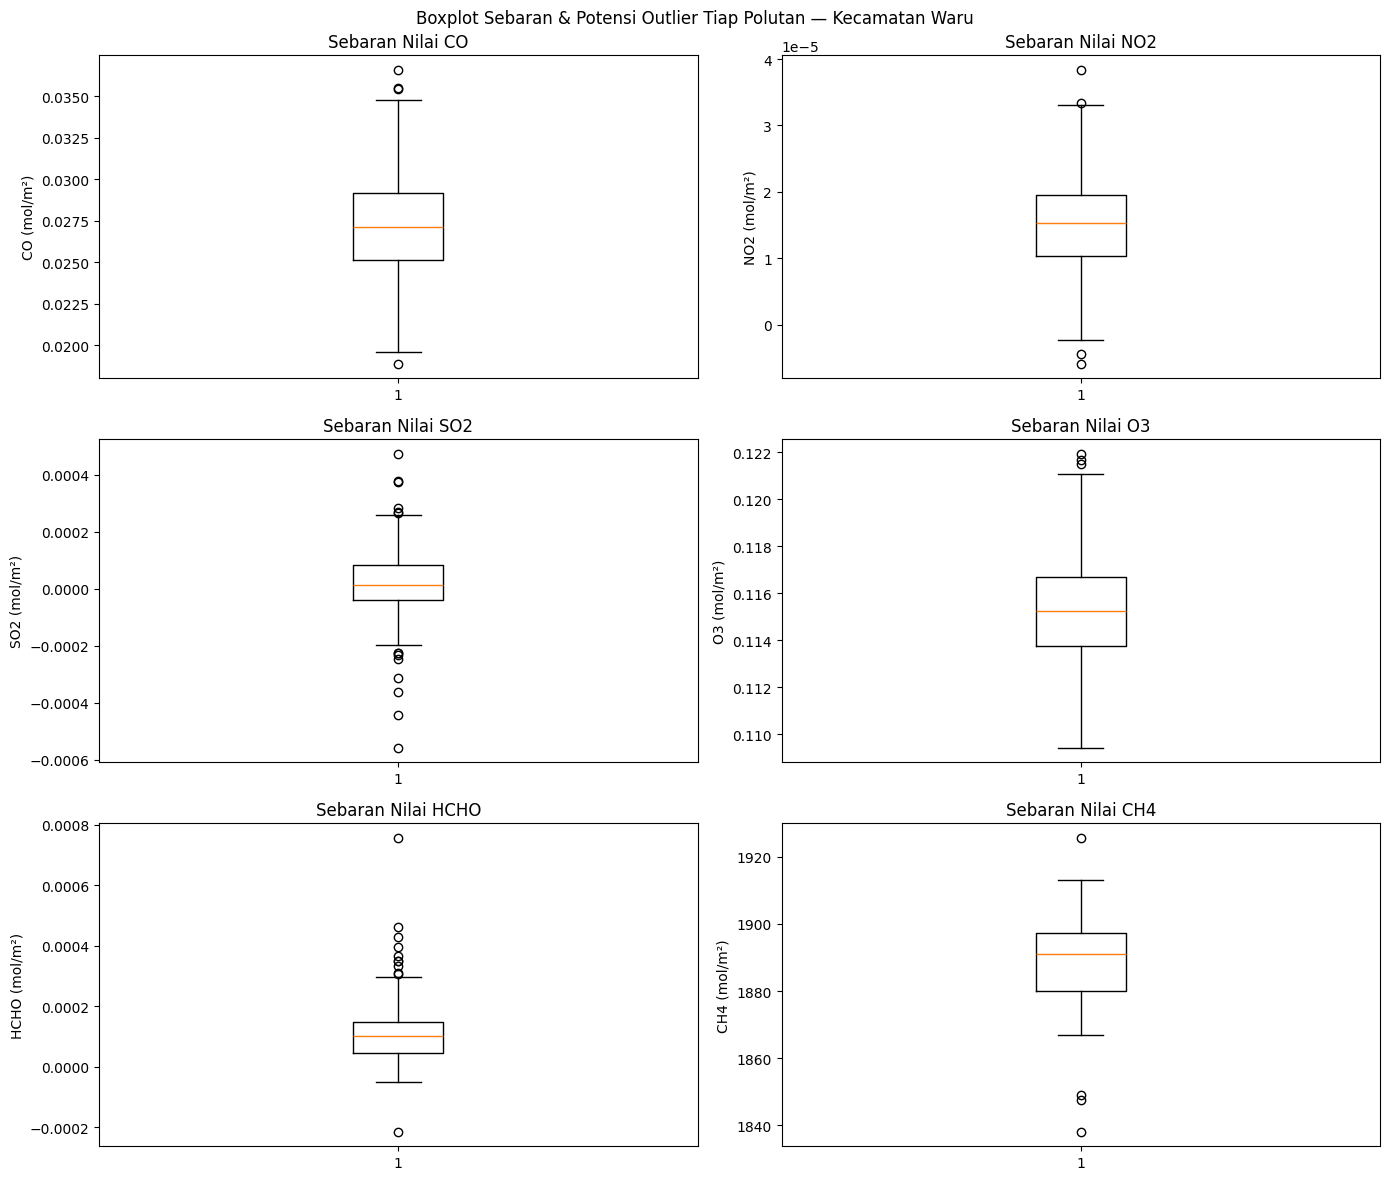

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for ax, gas in zip(axes.flatten(), daftar_polutan):
    ax.boxplot(df_polutan_waru[gas].dropna())
    ax.set_title(f"Sebaran Nilai {gas}")
    ax.set_ylabel(f"{gas} (mol/m²)")

fig.suptitle("Boxplot Sebaran & Potensi Outlier Tiap Polutan — Kecamatan Waru")
plt.tight_layout()
plt.show()


Penjelasan kode di atas adalah sebagai berikut.

- `plt.subplots(3, 2, ...)` membuat kanvas berisi 6 area gambar (3 baris × 2 kolom), satu untuk tiap polutan.
- Perulangan `for ax, gas in zip(axes.flatten(), daftar_polutan)` menggambar satu boxplot per polutan menggunakan data yang telah dibersihkan dari nilai kosong.
- Boxplot menampilkan posisi kuartil, median (garis tengah kotak), serta titik di luar *whisker* yang mengindikasikan potensi outlier secara visual.

> Perlu dicatat bahwa nilai negatif pada data kolom Sentinel-5P adalah hal yang **wajar** akibat *noise* sensor, terutama pada wilayah dengan konsentrasi gas yang rendah &mdash; sehingga tidak semua outlier hasil IQR otomatis berarti kesalahan data. Beberapa titik outlier justru bisa mengindikasikan kejadian nyata, misalnya musim pembakaran lahan pertanian sisa panen atau lonjakan aktivitas peternakan sapi Madura di Kecamatan Waru.


### 2.10 Visualisasi Time Series

Pada bagian ini dibuat dua jenis grafik: grafik gabungan yang telah dinormalisasi ke rentang 0–1 untuk membandingkan pola seluruh polutan dalam satu sumbu, serta grafik terpisah per polutan dengan skala aslinya agar perubahan masing-masing polutan — termasuk CH4 yang datanya sangat terbatas — tetap dapat teramati dengan jelas.

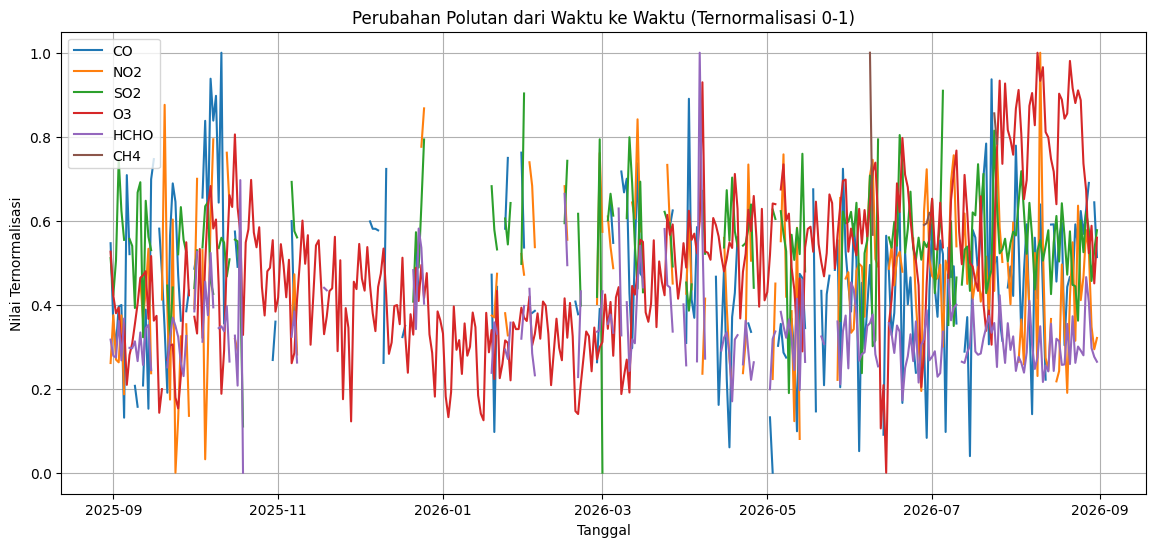

In [15]:
df_ternormalisasi = df_polutan_waru[daftar_polutan].copy()

for gas in daftar_polutan:
    nilai_min = df_ternormalisasi[gas].min()
    nilai_max = df_ternormalisasi[gas].max()
    df_ternormalisasi[gas] = (df_ternormalisasi[gas] - nilai_min) / (nilai_max - nilai_min)

plt.figure(figsize=(14, 6))

for gas in daftar_polutan:
    plt.plot(df_polutan_waru["tanggal"], df_ternormalisasi[gas], label=gas)

plt.title("Perubahan Polutan dari Waktu ke Waktu (Ternormalisasi 0-1)")
plt.xlabel("Tanggal")
plt.ylabel("Nilai Ternormalisasi")
plt.legend()
plt.grid()
plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- `df_ternormalisasi` adalah salinan data keenam polutan yang dinormalisasi satu per satu memakai rumus *min-max normalization*: `(nilai - min) / (max - min)`, sehingga seluruh nilai berada pada rentang 0–1.
- Perulangan kedua menggambar satu garis per polutan pada sumbu yang sama, sehingga pola kenaikan/penurunan seluruh gas dapat dibandingkan langsung meskipun satuan aslinya berbeda-beda.

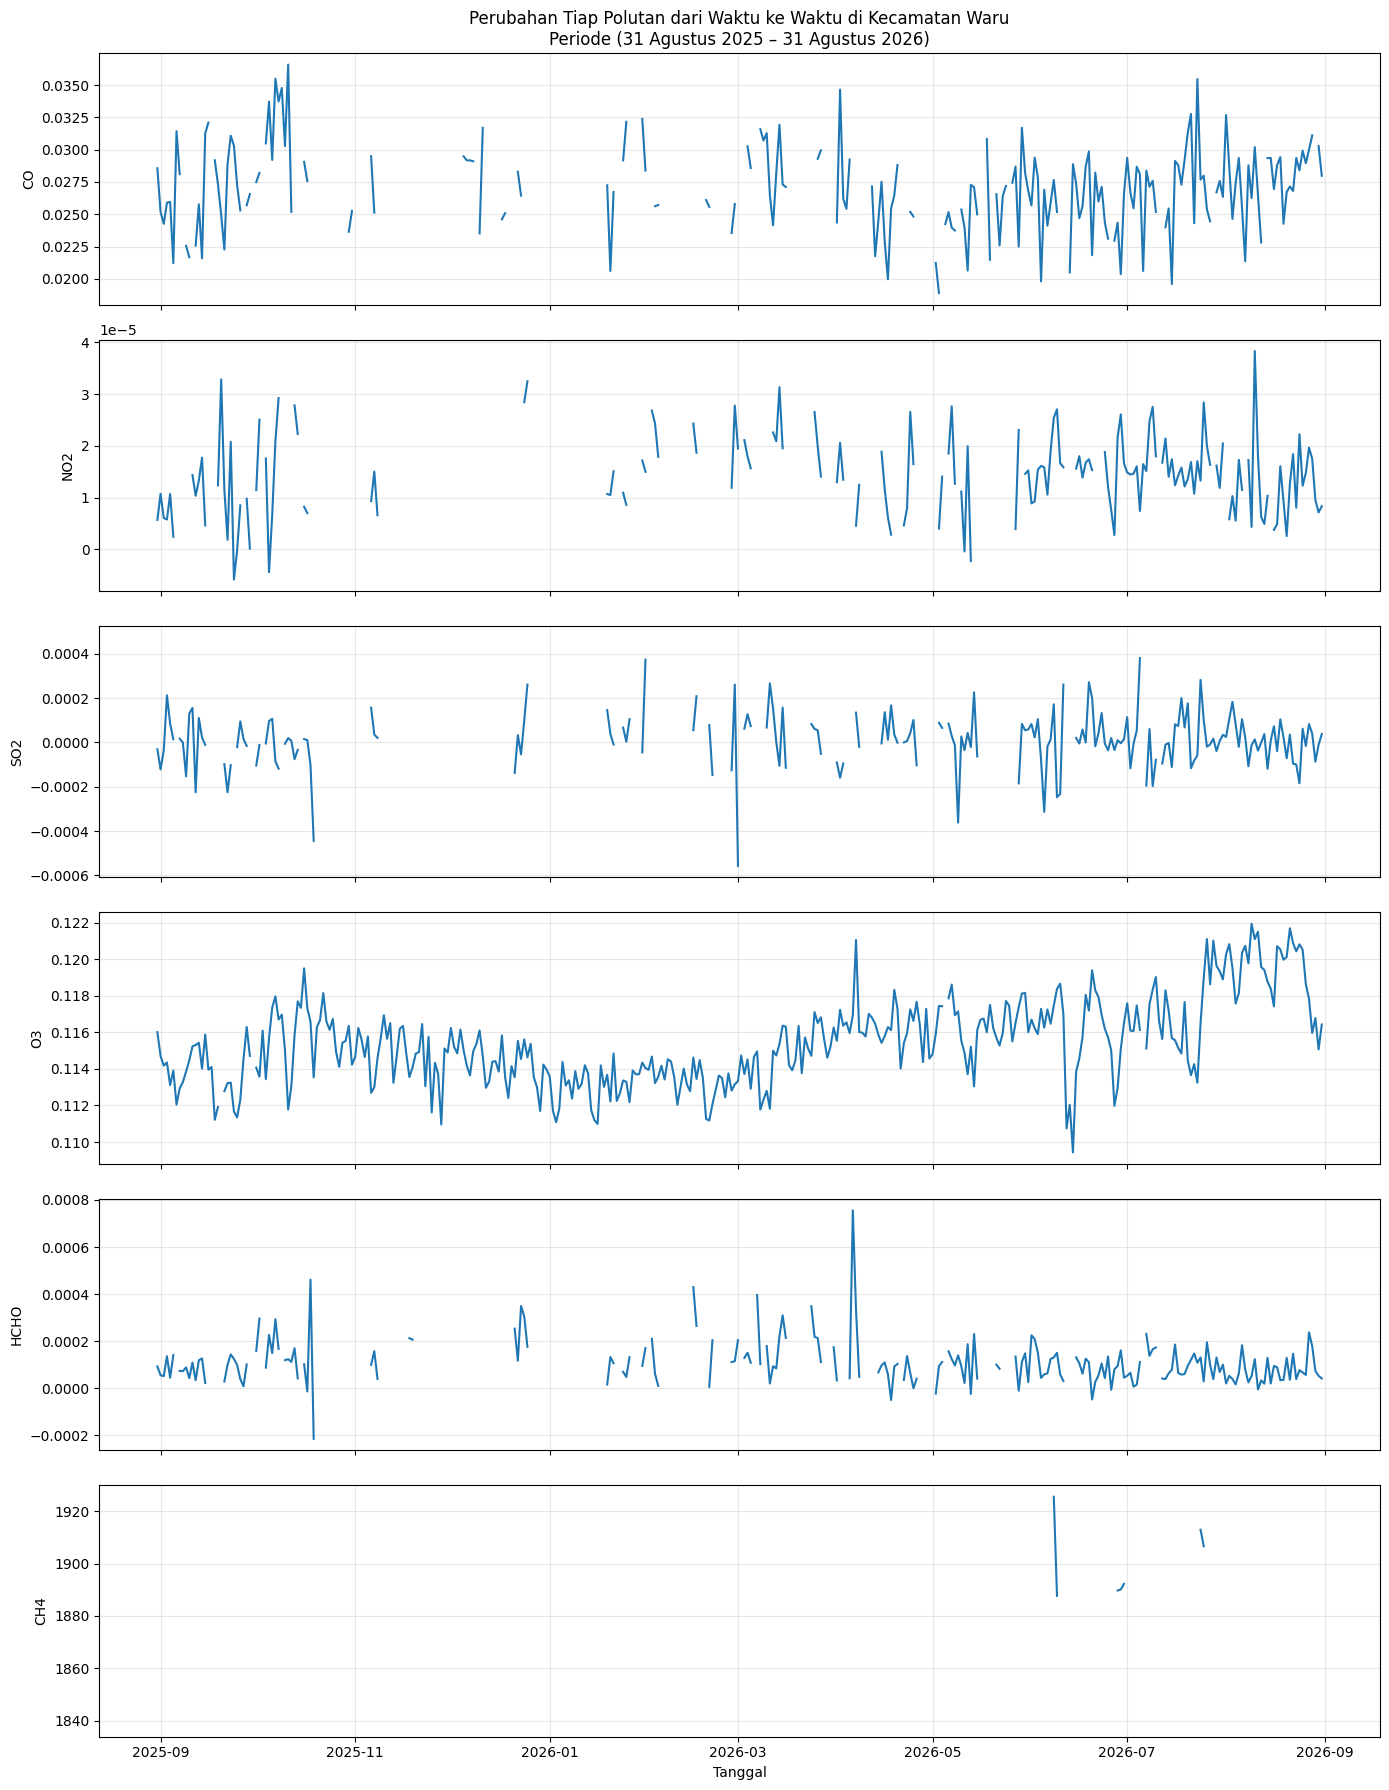

In [16]:
fig, axes = plt.subplots(len(daftar_polutan), 1, figsize=(14, 3 * len(daftar_polutan)), sharex=True)

for ax, gas in zip(axes, daftar_polutan):
    ax.plot(df_polutan_waru["tanggal"], df_polutan_waru[gas], color="tab:blue")
    ax.set_ylabel(gas)
    ax.grid(alpha=0.3)

axes[0].set_title("Perubahan Tiap Polutan dari Waktu ke Waktu di Kecamatan Waru\nPeriode (31 Agustus 2025 – 31 Agustus 2026)")
axes[-1].set_xlabel("Tanggal")

plt.tight_layout()
plt.show()

Penjelasan kode di atas adalah sebagai berikut.

- `plt.subplots(len(daftar_polutan), 1, ..., sharex=True)` membuat satu baris subplot per polutan (enam subplot bertumpuk) dengan sumbu tanggal yang selaras.
- Perulangan `for ax, gas in zip(axes, daftar_polutan)` menggambar data asli (tanpa normalisasi) tiap polutan pada subplot-nya masing-masing, sehingga skala nilai tiap gas — termasuk CH4 yang datanya sangat terbatas — tetap terlihat jelas tanpa "tenggelam".

## Kesimpulan

Melalui tugas ini, data konsentrasi enam polutan udara (CO, NO2, SO2, O3, HCHO, dan CH4) di Kecamatan Waru, Kabupaten Pamekasan berhasil diperoleh dari satelit Sentinel-5P menggunakan layanan openEO pada Copernicus Data Space Ecosystem, dengan wilayah analisa dibatasi melalui berkas GeoJSON batas administratif resmi Kecamatan Waru yang disederhanakan (simplify) sebelum dihitung *bounding box*-nya. Karena keterbatasan satu *band* per permintaan pada API, pengambilan data dilakukan bergiliran untuk tiap gas dan hasil akhirnya digabungkan menjadi satu berkas CSV. Tahap *data understanding* yang dilakukan mencakup pemeriksaan struktur dan isi data, deskripsi tiap fitur, identifikasi missing value (umumnya akibat tutupan awan), serta deteksi data anomali/outlier dengan metode IQR. Grafik *time series* yang dihasilkan menunjukkan pola fluktuasi tiap polutan sepanjang satu tahun pengamatan, yang diduga berkaitan dengan aktivitas pertanian, peternakan sapi Madura, serta lalu lintas kendaraan di wilayah Kecamatan Waru. Temuan tahap ini menjadi dasar bagi tahap pembersihan data dan pemodelan lanjutan pada pertemuan berikutnya.


# Penyimpanan Data ke PostgreSQL (Aiven) dan Penarikannya ke KNIME

## 1. Penyimpanan Data ke Basis Data (PostgreSQL — Aiven)

Selain disimpan dalam bentuk berkas CSV, data polutan yang telah diperoleh pada tahap sebelumnya juga dipindahkan ke basis data PostgreSQL yang di-hosting pada layanan Aiven. Langkah ini dilakukan agar data dapat diakses kembali secara terpusat, misalnya melalui KNIME Analytics Platform atau aplikasi lain, tanpa bergantung pada ketersediaan berkas lokal.

Seluruh kredensial koneksi (host, port, username, dan password) tidak dituliskan secara eksplisit di dalam kode, melainkan diambil melalui fitur Colab Secrets. Pendekatan ini diterapkan untuk mencegah kredensial tersebut ikut terekspos apabila notebook ini dibagikan atau diunggah ke repositori publik.

In [18]:
# membaca ulang CSV data_polutan_waru.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("data_polutan_waru.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("Polutan_waru", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "Polutan_waru" LIMIT 5', engine))

Berhasil! 366 baris terupload ke Aiven.
      tanggal        CO       NO2       SO2        O3      HCHO          CH4
0  2025-08-31  0.028565  0.000006 -0.000031  0.116010  0.000093          NaN
1  2025-09-01  0.025179  0.000011 -0.000122  0.114705  0.000055          NaN
2  2025-09-02  0.024256  0.000006 -0.000036  0.114179  0.000052          NaN
3  2025-09-03  0.025893  0.000006  0.000212  0.114352  0.000136          NaN
4  2025-09-04  0.025961  0.000011  0.000085  0.113113  0.000045  1849.052246


Penjelasan kode di atas adalah sebagai berikut.

- Fungsi `pd.read_csv("data_polutan_waru.csv")` digunakan untuk membaca kembali berkas CSV yang telah dihasilkan pada tahap *Data Understanding* sebelumnya.
- Kelima variabel kredensial (`AIVEN_USER`, `AIVEN_PASSWORD`, `AIVEN_HOST`, `AIVEN_PORT`, `AIVEN_DB`) diperoleh melalui `userdata.get()` dari Colab Secrets, bukan dituliskan secara langsung pada kode.
- Fungsi `create_engine()` digunakan untuk membentuk koneksi ke basis data PostgreSQL Aiven melalui driver `psycopg2`, dengan parameter `sslmode=require` karena Aiven mewajibkan koneksi yang terenkripsi.
- Fungsi `df_baru.to_sql("Polutan_waru", engine, if_exists="replace", index=False)` mengirimkan seluruh isi dataframe ke tabel `Polutan_waru` pada basis data tersebut. Parameter `if_exists="replace"` berarti tabel yang sudah ada sebelumnya akan digantikan dengan data terbaru.
- Dua baris `print()` pada bagian akhir kode berfungsi sebagai verifikasi, yaitu menampilkan jumlah baris yang berhasil diunggah beserta lima baris data teratas hasil kueri dari tabel tersebut.

## 2. Menarik Data dari PostgreSQL (Aiven) ke KNIME

Setelah data polutan tersimpan pada basis data Aiven, tahap selanjutnya adalah menarik data tersebut ke KNIME Analytics Platform untuk keperluan eksplorasi lebih lanjut. Alur kerja yang digunakan tersusun atas empat node yang saling terhubung secara berurutan, yaitu **PostgreSQL Connector**, **DB Table Selector**, **DB Reader**, dan **Statistics**.
   > ![image](https://hackmd.io/_uploads/r10KtLKOfl.png)

### 2.1 PostgreSQL Connector

Berfungsi membuka koneksi ke server Aiven. Konfigurasi yang diisikan meliputi hostname sesuai `AIVEN_HOST`, port sesuai `AIVEN_PORT`, nama basis data `defaultdb`, serta username dan password sesuai kredensial Aiven, dengan SSL Mode diatur ke `require` karena Aiven mewajibkan koneksi terenkripsi. Dua port opsional pada bagian atas node dapat digunakan untuk menyuntikkan kredensial melalui flow variable; apabila tidak dihubungkan, username dan password dapat diisikan langsung pada tab konfigurasi node.

   > ![image](https://hackmd.io/_uploads/SJlKc8tOfg.png)

### 2.2 DB Table Selector

Dihubungkan ke output PostgreSQL Connector, kemudian digunakan untuk memilih tabel `Polutan_waru` yang sebelumnya telah dibuat melalui fungsi `to_sql()`.

  > ![image](https://hackmd.io/_uploads/rkZknYzKMg.png)

### 2.3 DB Reader

Mengeksekusi kueri dari DB Table Selector dan mengonversi hasilnya menjadi tabel KNIME biasa, sehingga siap diproses oleh node analisis berikutnya.

  > ![image](https://hackmd.io/_uploads/rk7m2tzFfl.png)

### 2.4 Statistics

Dihubungkan langsung ke output DB Reader dan digunakan untuk menghitung ringkasan statistik (mean, median, standar deviasi, variance, min, max, kuartil, skewness, kurtosis, dan sebagainya) untuk setiap kolom polutan. Node ini memiliki tiga output port, yaitu Statistics Table, Nominal Histogram Table, dan Occurrences Table.

   > ![image](https://hackmd.io/_uploads/HkXYFTtOzl.png)

   > ![image](https://hackmd.io/_uploads/H1Vq2KMKfl.png)

   > ![image](https://hackmd.io/_uploads/Sy_q2YMFMg.png)


Beberapa ukuran statistik yang dihasilkan oleh node ini meliputi:

- **Min**, yaitu nilai terkecil pada kolom.
- **Max**, yaitu nilai terbesar pada kolom.
- **Mean**, yaitu nilai rata-rata data.
- **Variance**, yaitu ukuran penyebaran data terhadap nilai rata-ratanya.
- **Std. Deviation**, yaitu akar dari variance yang lebih mudah diinterpretasikan karena memiliki satuan yang sama dengan data asli.
- **Skewness**, yaitu ukuran kemencengan (asimetri) distribusi data.
- **Kurtosis**, yaitu ukuran keruncingan distribusi data dibandingkan dengan distribusi normal.
- **Overall Sum**, yaitu jumlah seluruh nilai numerik pada kolom.
- **No. Missings**, yaitu jumlah baris yang tidak memiliki nilai pada kolom tersebut.
- **No. NaNs**, yaitu jumlah nilai yang secara eksplisit bertipe *Not a Number*.
- **No. +oos** dan **No. -oos**, yaitu jumlah nilai positif dan negatif yang berada di luar batas (*out of spec*) yang ditetapkan.
- **Median**, yaitu nilai tengah data setelah diurutkan.
- **Row Count**, yaitu jumlah seluruh baris tabel, termasuk baris yang bernilai *missing*. Perlu digarisbawahi bahwa Row Count berbeda dengan jumlah data yang benar-benar digunakan dalam perhitungan Mean, Variance, dan statistik numerik lainnya, karena nilai *missing* tidak diikutsertakan dalam perhitungan tersebut.

## 3. Ilustrasi Perhitungan Statistik

Sebagai ilustrasi cara kerja node Statistics, diambil data kolom **NO2** pada lima baris pertama data Kecamatan Waru:

| Hari | Tanggal | NO2 |
|---|---|---|
| 1 | 2025-08-31 | 0,000006 |
| 2 | 2025-09-01 | 0,000011 |
| 3 | 2025-09-02 | 0,000006 |
| 4 | 2025-09-03 | 0,000006 |
| 5 | 2025-09-04 | 0,000011 |

Seluruh nilai NO2 pada lima baris pertama ini tercatat lengkap (tidak ada yang kosong), sehingga banyaknya data yang dipakai dalam perhitungan berikut adalah $n = 5$.

### 3.1 Min

Min adalah nilai paling kecil di antara seluruh data yang tersedia.

$$\text{Min} = \min(x_1, x_2, \dots, x_n)$$

$$\text{Min} = \min(0{,}000006;\ 0{,}000011;\ 0{,}000006;\ 0{,}000006;\ 0{,}000011) = 0{,}000006$$

Sehingga Min NO2 = 0,000006.

### 3.2 Max

Kebalikan dari Min, Max adalah nilai paling besar di antara data yang ada.

$$\text{Max} = \max(x_1, x_2, \dots, x_n)$$

$$\text{Max} = \max(0{,}000006;\ 0{,}000011;\ 0{,}000006;\ 0{,}000006;\ 0{,}000011) = 0{,}000011$$

Sehingga Max NO2 = 0,000011.

### 3.3 Mean

Mean merupakan nilai rata-rata dari seluruh data numerik yang tersedia.

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

$$\bar{x} = \frac{0{,}000006 + 0{,}000011 + 0{,}000006 + 0{,}000006 + 0{,}000011}{5} = \frac{0{,}000040}{5} = 0{,}000008$$

Sehingga Mean NO2 = 0,000008.

### 3.4 Variance

Variance menunjukkan besarnya penyebaran data terhadap nilai rata-ratanya. Pada contoh ini digunakan rumus *sample variance*:

$$s^2 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}$$

Dengan $\bar{x} = 0{,}000008$, selisih tiap nilai terhadap mean beserta kuadratnya adalah sebagai berikut:

| $x_i$ | $x_i - \bar{x}$ | $(x_i-\bar{x})^2$ |
|---|---|---|
| 0,000006 | -0,000002 | 0,000000000004 |
| 0,000011 | 0,000003 | 0,000000000009 |
| 0,000006 | -0,000002 | 0,000000000004 |
| 0,000006 | -0,000002 | 0,000000000004 |
| 0,000011 | 0,000003 | 0,000000000009 |

Jumlah seluruh kuadrat selisih tersebut $= 0{,}00000000003$ (atau $3 \times 10^{-11}$), sehingga:

$$s^2 = \frac{0{,}00000000003}{5-1} = 0{,}0000000000075 \approx 7{,}5 \times 10^{-12}$$

Diperoleh Variance NO2 ≈ $7{,}5 \times 10^{-12}$.

### 3.5 Std. Deviation

Standar deviasi merupakan akar dari variance, dan lebih mudah diinterpretasikan karena satuannya sama dengan data aslinya.

$$s = \sqrt{s^2} = \sqrt{7{,}5 \times 10^{-12}} \approx 0{,}0000027386$$

Diperoleh Std. Deviation NO2 ≈ 0,0000027386 (atau $2{,}7386 \times 10^{-6}$).

### 3.6 Skewness

Skewness mengukur tingkat kemencengan (asimetri) distribusi data, menggunakan rumus *corrected sample skewness*:

$$G_1 = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3$$

Dengan $n = 5$, $\bar{x} = 0{,}000008$, dan $s \approx 0{,}0000027386$, diperoleh:

$$G_1 \approx 0{,}6086$$

Nilai Skewness NO2 ≈ 0,6086 ini bertanda positif, menandakan distribusi data pada lima baris ini sedikit condong ke arah kanan (didominasi nilai rendah dengan dua nilai yang relatif lebih tinggi).

### 3.7 Kurtosis

Kurtosis menggambarkan tingkat keruncingan distribusi dibandingkan distribusi normal, dihitung dengan rumus *corrected sample excess kurtosis*:

$$G_2 = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$$

Dengan $n = 5$, hasil perhitungannya:

$$G_2 \approx -3{,}3333$$

Nilai Kurtosis NO2 ≈ -3,3333 yang negatif ini mengindikasikan bahwa distribusi data pada lima baris ini lebih landai (lebih menyebar rata ke dua kelompok nilai) dibandingkan distribusi normal.

### 3.8 Overall Sum

Overall Sum adalah total penjumlahan seluruh nilai numerik yang tersedia pada kolom tersebut.

$$\text{Sum} = \sum_{i=1}^{n} x_i$$

$$\text{Sum} = 0{,}000006 + 0{,}000011 + 0{,}000006 + 0{,}000006 + 0{,}000011 = 0{,}000040$$

Sehingga Overall Sum NO2 = 0,000040.

### 3.9 No. Missings

Fitur ini mencatat jumlah baris yang tidak memiliki nilai (kosong) pada kolom tersebut. Karena pada lima baris pertama ini seluruh data NO2 terisi lengkap:

$$\text{No. Missings} = 0$$

### 3.10 No. NaNs

Berbeda dari missing value, No. NaNs khusus menghitung nilai yang secara eksplisit bertipe *Not a Number*. Pada contoh ini juga tidak ditemukan nilai semacam itu:

$$\text{No. NaNs} = 0$$

### 3.11 No. +oos

Fitur ini menunjukkan banyaknya nilai positif yang berada di luar batas (*out of spec*) yang ditetapkan. Tidak ada data pada contoh ini yang termasuk kategori tersebut:

$$\text{No. } {+oos} = 0$$

### 3.12 No. -oos

Sebaliknya, fitur ini menghitung nilai negatif yang berada di luar batas yang ditetapkan. Pada contoh ini juga tidak ditemukan data semacam itu:

$$\text{No. } {-oos} = 0$$

### 3.13 Median

Median merupakan nilai yang berada tepat di tengah setelah data diurutkan. Data yang telah diurutkan:

$$0{,}000006;\ 0{,}000006;\ 0{,}000006;\ 0{,}000011;\ 0{,}000011$$

Karena jumlah data ganjil ($n = 5$), median diambil langsung dari nilai tengah (data ke-3):

$$\text{Median} = x_{(3)} = 0{,}000006$$

Sehingga Median NO2 = 0,000006.

### 3.14 Row Count

Row Count menghitung seluruh baris pada tabel, termasuk yang bernilai missing. Pada contoh ini terdapat 5 baris:

$$\text{Row Count} = 5$$

Perlu digarisbawahi bahwa Row Count tidak selalu sama dengan jumlah data yang dipakai dalam perhitungan Mean, Variance, dan statistik numerik lainnya — pada contoh ini kebetulan sama karena tidak ada nilai yang kosong, namun akan berbeda bila salah satu barisnya missing (seperti pada kolom CH4, yang sebagian datanya belum tersedia pada rentang lima baris ini).


## Kesimpulan

Data polutan yang telah tersimpan sebagai CSV diunggah ke basis data PostgreSQL (Aiven), dengan kredensial disimpan lewat Colab Secrets agar tidak ikut terekspos. Data tersebut kemudian ditarik ke KNIME melalui alur empat node — PostgreSQL Connector, DB Table Selector, DB Reader, dan Statistics — untuk menghasilkan ringkasan statistik tiap polutan secara otomatis. Hasilnya sejalan dengan perhitungan manual pada bagian sebelumnya, sehingga proses penyimpanan dan penarikan data antara Aiven dan KNIME dapat dipastikan berjalan dengan benar.

# Ekstraksi 68 Fitur Time Series NO2 Menggunakan Library TSFEL

## 1. Data Preparation
### 1.1 Instalasi Library


In [19]:
!pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.0 MB/s eta 0:00:00


Penjelasan kode di atas adalah sebagai berikut.

- Baris `!pip install tsfel` memasang pustaka `tsfel` (*Time Series Feature Extraction Library*), yang menyediakan kumpulan fungsi siap pakai untuk menghitung berbagai fitur statistik, spektral, temporal, dan fraktal dari sinyal deret waktu.


### 1.2 Deteksi Outlier, Imputasi Missing Value, dan Ekstraksi 68 Fitur TSFEL

In [20]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('data_polutan_waru.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('tanggal').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_waru_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 173
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


Penjelasan kode di atas adalah sebagai berikut.

- Berkas `data_polutan_waru.csv` (hasil tahap *Data Understanding* sebelumnya) dibaca kembali, kolom `tanggal` dikonversi ke tipe datetime, lalu data diurutkan berdasarkan tanggal.
- Kolom `NO2` dipaksa menjadi tipe numerik dengan `pd.to_numeric(..., errors="coerce")`; nilai yang gagal dikonversi (misalnya teks atau format tidak valid) otomatis diubah menjadi `NaN`, dan jumlahnya dicetak untuk keperluan pengecekan.
- **Deteksi outlier** dilakukan dengan metode IQR: kuartil pertama (`Q1`) dan ketiga (`Q3`) dihitung, lalu nilai NO2 yang berada di luar rentang `[Q1 - 1,5×IQR, Q3 + 1,5×IQR]` ditandai sebagai outlier dan diubah menjadi `NaN` (bukan dihapus barisnya, supaya deret tanggal tetap utuh).
- **Imputasi missing value** dilakukan dengan `interpolate(method="time")`, yang mengisi nilai kosong berdasarkan posisi tanggalnya secara proporsional, kemudian sisa nilai kosong di ujung awal/akhir data (yang tidak bisa diinterpolasi) diisi dengan `ffill()` dan `bfill()`, sehingga data akhir (`df_clean`) sudah bersih tanpa `NaN`.
- Kolom `NO2` yang telah bersih diambil sebagai array satu dimensi (`signal_1d`), dengan `fs = 1` menandakan frekuensi sampling satu observasi per hari.
- Variabel `FEATURE_LIST` memuat 68 nama fungsi fitur dari `tsfel`, meliputi fitur statistik dasar (`calc_mean`, `calc_std`, `skewness`, `kurtosis`), fitur spektral (`spectral_entropy`, `spectral_centroid`), fitur fraktal (`hurst_exponent`, `petrosian_fractal_dimension`), fitur wavelet, dan lainnya.
- Fungsi `to_scalar()` memastikan setiap hasil ekstraksi menjadi satu nilai tunggal — beberapa fungsi TSFEL (misalnya `mfcc`, `lpcc`) menghasilkan larik/array, sehingga dirata-ratakan (`np.nanmean`) agar dapat disimpan sebagai satu kolom.
- Fungsi `extract_one()` memanggil satu fungsi fitur berdasarkan namanya, dan secara otomatis menyertakan parameter `fs` hanya jika fungsi tersebut memang membutuhkannya (dicek melalui `inspect.signature`).
- Perulangan terakhir menjalankan `extract_one()` untuk seluruh 68 fitur pada `signal_1d`, hasilnya dikumpulkan ke dalam `row`, lalu diubah menjadi satu baris `DataFrame` (`extracted_features_final`) dan disimpan sebagai berkas `NO2_waru_TSFEL.csv`.


### 1.3 Membaca Berkas NO2_waru_TSFEL

In [21]:
hasil_ekstraksi = pd.read_csv("NO2_waru_TSFEL.csv")

print("Ukuran data:", hasil_ekstraksi.shape)
display(hasil_ekstraksi)

Ukuran data: (1, 68)


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,1.123197e-07,0.005901,5.0,3.077253e-10,168.84489,0.000033,0.000016,0.000016,-0.000002,0.000007,...,0.148818,0.422768,7.722150e-11,0.001353,6.737109e-07,0.00001,2.142401,0.00001,1.046791e-10,6.0



Penjelasan kode di atas adalah sebagai berikut.

- `pd.read_csv("NO2_waru_TSFEL.csv")` membaca kembali berkas hasil ekstraksi fitur yang sudah disimpan sebelumnya, untuk memverifikasi isinya sebelum diunggah ke situs pengumpulan tugas.
- `.shape` menampilkan ukuran datanya — dan sesuai output, hasilnya `(1, 68)`, artinya 1 baris data dengan 68 kolom fitur, persis sesuai target 68 fitur TSFEL yang diminta.
- `display(hasil_ekstraksi)` menampilkan tabelnya secara langsung di Colab sebagai pengecekan visual, bukan cuma lewat `print()` biasa (supaya format tabelnya lebih rapi dan mudah dibaca).

Gambar berikut menunjukkan hasil eksekusi kode ekstraksi fitur di atas. Proses berjalan tanpa nilai kosong yang tersisa, dan seluruh 68 fitur berhasil dihitung serta disimpan ke dalam berkas `NO2_Waru_TSFEL.csv`.

> ![image](https://hackmd.io/_uploads/B1_rzcMKMg.png)

Berkas `NO2_Waru_TSFEL.csv` yang dihasilkan kemudian dibuka kembali untuk diperiksa isinya. Berkas ini terdiri atas satu baris data dengan 68 kolom, masing-masing mewakili satu nilai fitur (statistik, spektral, temporal, maupun fraktal) yang merepresentasikan keseluruhan sinyal NO2 Kecamatan Waru selama periode pengamatan.

> ![image](https://hackmd.io/_uploads/SJBvM9MFMl.png)

### 1.4 Penjelasan Fitur Ekstraksi TSFEL

TSFEL mengelompokkan fitur ke dalam 4 domain resmi: *Statistical*, *Temporal*, *Spectral*, dan *Fractal*. Total fitur yang diekstraksi pada kode di atas berjumlah 68 fitur (21 + 15 + 26 + 6).

#### 1.4.1 Domain Statistical (21 fitur)

Mengukur karakteristik distribusi nilai sinyal, tanpa memperhatikan urutan waktu.

- **`abs_energy`** &mdash; menghitung total energi absolut sinyal (jumlah kuadrat seluruh nilai).
- **`average_power`** &mdash; menghitung daya rata-rata sinyal per satuan waktu.
- **`calc_max`** &mdash; mengambil nilai maksimum sinyal.
- **`calc_mean`** &mdash; menghitung nilai rata-rata sinyal.
- **`calc_median`** &mdash; mengambil nilai tengah sinyal setelah diurutkan.
- **`calc_min`** &mdash; mengambil nilai minimum sinyal.
- **`calc_std`** &mdash; menghitung standar deviasi (sebaran) sinyal.
- **`calc_var`** &mdash; menghitung variansi sinyal.
- **`ecdf`** &mdash; menghitung nilai fungsi distribusi kumulatif empiris (ECDF) sepanjang sinyal.
- **`ecdf_percentile`** &mdash; mengambil nilai sinyal pada persentil tertentu dari ECDF.
- **`ecdf_percentile_count`** &mdash; menghitung jumlah sampel kumulatif di bawah persentil tertentu.
- **`ecdf_slope`** &mdash; menghitung kemiringan (slope) ECDF antara dua persentil.
- **`entropy`** &mdash; mengukur tingkat ketidakteraturan/keacakan sinyal (Shannon entropy).
- **`hist_mode`** &mdash; mengambil modus (nilai paling sering muncul) dari histogram sinyal.
- **`interq_range`** &mdash; menghitung rentang interkuartil (Q3−Q1), ukuran sebaran data tengah.
- **`kurtosis`** &mdash; mengukur keruncingan distribusi sinyal dibanding distribusi normal.
- **`mean_abs_deviation`** &mdash; menghitung rata-rata deviasi absolut dari mean.
- **`median_abs_deviation`** &mdash; menghitung median deviasi absolut dari median.
- **`pk_pk_distance`** &mdash; menghitung jarak antara nilai maksimum dan minimum (*peak-to-peak*).
- **`rms`** &mdash; menghitung *root mean square*, ukuran magnitudo keseluruhan sinyal.
- **`skewness`** &mdash; mengukur kemencengan/asimetri distribusi sinyal.

### 1.4.2 Domain Temporal (15 fitur)

Mengukur pola perubahan sinyal terhadap waktu (urutan data diperhatikan).

- **`auc`** &mdash; menghitung luas area di bawah kurva sinyal (*area under curve*).
- **`autocorr`** &mdash; mencari lag pertama saat autokorelasi turun di bawah 1/e, mengukur seberapa mirip sinyal dengan versi tergesernya.
- **`calc_centroid`** &mdash; menghitung titik pusat (*centroid*) sinyal di sepanjang sumbu waktu.
- **`distance`** &mdash; menghitung total jarak tempuh sinyal dari titik ke titik.
- **`lempel_ziv`** &mdash; mengukur kompleksitas Lempel-Ziv, seberapa "acak"/tidak berulang pola sinyal.
- **`mean_abs_diff`** &mdash; menghitung rata-rata selisih absolut antar titik berurutan.
- **`mean_diff`** &mdash; menghitung rata-rata selisih (bertanda) antar titik berurutan.
- **`median_abs_diff`** &mdash; menghitung median selisih absolut antar titik berurutan.
- **`median_diff`** &mdash; menghitung median selisih antar titik berurutan.
- **`negative_turning`** &mdash; menghitung jumlah titik balik negatif (dari naik ke turun).
- **`neighbourhood_peaks`** &mdash; menghitung jumlah puncak lokal berdasarkan wilayah tetangga tertentu.
- **`positive_turning`** &mdash; menghitung jumlah titik balik positif (dari turun ke naik).
- **`slope`** &mdash; menghitung kemiringan garis tren linear sinyal terhadap waktu.
- **`sum_abs_diff`** &mdash; menghitung total selisih absolut antar titik berurutan.
- **`zero_cross`** &mdash; menghitung berapa kali sinyal melewati nilai nol (berganti tanda).

### 1.4.3 Domain Spectral (26 fitur)

Mengubah sinyal ke ranah frekuensi (lewat FFT/wavelet) lalu mengukur karakteristiknya di sana.

- **`fundamental_frequency`** &mdash; mencari frekuensi dominan/utama pada sinyal.
- **`human_range_energy`** &mdash; menghitung rasio energi sinyal pada rentang 0,6&ndash;2,5 Hz terhadap total energi.
- **`lpcc`** &mdash; menghitung koefisien cepstral prediksi linear (*Linear Prediction Cepstral Coefficients*).
- **`max_frequency`** &mdash; mencari frekuensi di mana 95% energi sinyal sudah terkumpul secara kumulatif.
- **`max_power_spectrum`** &mdash; mengambil nilai maksimum kerapatan daya spektral sinyal.
- **`median_frequency`** &mdash; mencari frekuensi di mana 50% energi sinyal sudah terkumpul.
- **`mfcc`** &mdash; menghitung koefisien cepstral Mel-frequency, representasi spektrum dalam skala mel.
- **`power_bandwidth`** &mdash; menghitung lebar pita frekuensi yang mengandung 95% daya sinyal.
- **`spectral_centroid`** &mdash; menghitung titik pusat massa (*barycenter*) spektrum frekuensi.
- **`spectral_decrease`** &mdash; mengukur seberapa besar penurunan amplitudo spektrum seiring naiknya frekuensi.
- **`spectral_distance`** &mdash; menghitung jarak spektrum kumulatif sinyal terhadap garis regresi linearnya.
- **`spectral_entropy`** &mdash; mengukur entropi (ketidakteraturan) dari distribusi energi spektral.
- **`spectral_kurtosis`** &mdash; mengukur keruncingan distribusi spektrum frekuensi.
- **`spectral_positive_turning`** &mdash; menghitung jumlah titik balik positif pada magnitude hasil FFT.
- **`spectral_roll_off`** &mdash; mencari frekuensi di mana 95% energi spektrum berada di bawahnya.
- **`spectral_roll_on`** &mdash; mencari frekuensi di mana 5% energi spektrum berada di bawahnya.
- **`spectral_skewness`** &mdash; mengukur kemencengan/asimetri distribusi spektrum frekuensi.
- **`spectral_slope`** &mdash; menghitung kemiringan garis regresi linear dari amplitudo spektrum.
- **`spectral_spread`** &mdash; mengukur sebaran spektrum di sekitar titik centroid-nya.
- **`spectral_variation`** &mdash; mengukur seberapa besar variasi spektrum antar waktu (korelasi silang dua spektrum berurutan).
- **`spectrogram_mean_coeff`** &mdash; menghitung rata-rata kerapatan daya spektral tiap bin frekuensi sepanjang durasi sinyal.
- **`wavelet_abs_mean`** &mdash; menghitung rata-rata absolut koefisien wavelet tiap skala.
- **`wavelet_energy`** &mdash; menghitung energi koefisien wavelet tiap skala.
- **`wavelet_entropy`** &mdash; mengukur entropi dari distribusi energi wavelet antarskala.
- **`wavelet_std`** &mdash; menghitung standar deviasi koefisien wavelet tiap skala.
- **`wavelet_var`** &mdash; menghitung variansi koefisien wavelet tiap skala.

### 1.4.4 Domain Fractal / Kompleksitas (6 fitur)

Mengukur kompleksitas dan sifat "memori jangka panjang" sinyal.

- **`dfa`** &mdash; menghitung *Detrended Fluctuation Analysis*, mengukur ada tidaknya korelasi/pola jangka panjang pada sinyal, meski sinyalnya tidak stasioner.
- **`higuchi_fractal_dimension`** &mdash; menghitung dimensi fraktal sinyal dengan metode Higuchi, mengukur seberapa "kasar/rumit" bentuk sinyal.
- **`hurst_exponent`** &mdash; menghitung eksponen Hurst lewat analisis *Rescaled Range* (R/S), mengindikasikan apakah sinyal cenderung persisten, acak, atau anti-persisten dari waktu ke waktu.
- **`maximum_fractal_length`** &mdash; menghitung *Maximum Fractal Length* (MFL), panjang rata-rata sinyal pada skala terkecil, diukur dari plot logaritmik penentuan dimensi fraktal.
- **`mse`** &mdash; menghitung *Multiscale Entropy*, mengukur tingkat ketidakteraturan sinyal pada berbagai skala waktu sekaligus.
- **`petrosian_fractal_dimension`** &mdash; menghitung dimensi fraktal Petrosian, versi lebih ringan/cepat dihitung dibanding metode Higuchi, tetap mengukur kompleksitas bentuk sinyal.



## Kesimpulan

Melalui tahap ini, sinyal deret waktu NO2 Kecamatan Waru yang telah melalui proses deteksi outlier (metode IQR) dan imputasi missing value (interpolasi berbasis waktu) berhasil diringkas menjadi 68 fitur menggunakan pustaka TSFEL, mencakup fitur statistik, spektral, temporal, dan fraktal. Hasil ekstraksi disimpan sebagai satu baris data pada berkas `NO2_Waru_TSFEL.csv`, yang selanjutnya diunggah tanpa perubahan apa pun ke situs pengumpulan tugas kelompok beserta nama dan kecamatan yang diambil, untuk kemudian digabungkan dengan hasil ekstraksi kecamatan lain pada basis data bersama.
